# Trabalho de APM - Regressão - G13

### 1. Importar bibliotecas

In [26]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd

# Pré-processamento
from sklearn.preprocessing import MinMaxScaler

# Seleção de modelo
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.model_selection import GridSearchCV, ParameterGrid

# Modelos
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Metricas
from sklearn.metrics import  mean_squared_error, mean_absolute_error, r2_score

# Graficos
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

%config InlineBackend.figure_format = 'svg'
#import joblib

### 2. Macro definições

In [27]:
# Bases de dados
DF_ADMISSAO = "Admissao - Dados.csv"
DF_BIOMASSA = "Biomassa - Dados.csv"

# Novos dados
DADOS_NOVOS_ADMISSAO = "Admissao - Novos Casos.csv"
DADOS_NOVOS_BIOMASSA = "Biomassa - Novos Casos.csv"

# Seed Global
RAND_SEED = 202613 # Ano atual + número do Grupo
np.random.seed(RAND_SEED)

# Tamanho da base de teste: 30%
TEST_SIZE = 0.3

# Largura máxima das colunas a serem exibidas
pd.set_option('display.max_colwidth', None)

### 3. Funções locais

In [28]:
# Carrega DataFrame
def load_df(df_name, column_to_drop=""):
    """Função para carregar o csv e se informado, remover colunas"""
    try:
        df = pd.read_csv(df_name, sep=',')
        if column_to_drop:
            df = df.drop(column_to_drop, axis=1)
        return df
    
    except:
        print("Erro ao processar o arquivo", df_name)

In [29]:
# Função para executar o experimento

def executar_experimento(config, X, y, test_size=TEST_SIZE):

    modelo = config["modelo"]
    parametros = config["parametros"]

    # ======================================================
    # HOLD-OUT
    # ======================================================
    if config["avaliacao"] == "hold_out":

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=RAND_SEED
        )

        melhor_score = -1
        melhor_param = None

        for p in ParameterGrid(parametros):
            modelo.set_params(**p)
            modelo.fit(X_train, y_train)

            y_pred = modelo.predict(X_test)
            score = r2_score(y_test, y_pred)

            if score > melhor_score:
                melhor_score = score
                melhor_param = p

        return {
            "melhor_parametro": melhor_param,
            "R2": round(melhor_score, 2),
            "Syx": np.round(np.std(y_test - y_pred, ddof=1),2),
            "Pearson" : np.round(np.corrcoef(y_test, y_pred)[0, 1],2),
            "RMSE": np.round(np.sqrt(mean_squared_error(y_test, y_pred)),2),
            "MAE": np.round(mean_absolute_error(y_test, y_pred),2),
            "modelo": modelo
        }

    # ======================================================
    # CROSS-VALIDATION
    # ======================================================
    elif config["avaliacao"] == "cross_validation":

        grid = GridSearchCV(
            estimator=modelo,
            param_grid=parametros,
            cv=config.get("cv", 5),
            scoring=config["metrica"],
            n_jobs=-1
        )
        
        grid.fit(X, y)
        y_pred = cross_val_predict(modelo, X, y, cv=config.get("cv", 5)) # Predições fora da amostra

        return {
            "melhor_parametro": grid.best_params_,
            "R2": round(grid.best_score_, 2),
            "Syx": np.round(np.std(y - y_pred, ddof=1),2),
            "Pearson" : np.round(np.corrcoef(y, y_pred)[0, 1],2),
            "RMSE": np.round(np.sqrt(mean_squared_error(y, y_pred)),2),
            "MAE": np.round(mean_absolute_error(y, y_pred),2),
            "modelo": grid.best_estimator_
        }

    else:
        raise ValueError(
            f"Tipo de avaliação inválido: {config['avaliacao']}"
        )


In [30]:
# Função que treina os modelos para uma base de dados (X e y) e retorna o resultado do experimento

def testa_modelos(modelos, X, y):
    # Dicionário para armazenar os resultados
    resultados = {}

    # Percorre todos os modelos configurados
    for chave, config in modelos.items():

        print(f"Executando: {config['nome']}")

        try:
            resultado = executar_experimento(config, X, y)

            # Guarda o resultado completo
            resultados[chave] = {
                "nome": config["nome"],
                "avaliacao": config["avaliacao"],
                "metrica": config["metrica"],
                "melhor_parametro": resultado["melhor_parametro"],
                "R2": resultado["R2"],
                "Syx": resultado["Syx"],
                "Pearson": resultado["Pearson"],
                "RMSE": resultado["RMSE"],
                "MAE": resultado["MAE"],
                "modelo": resultado["modelo"]
            }

            print(f"  Melhor score: {resultado['R2']:.2f}")
            print(f"  Melhor parâmetro: {resultado['melhor_parametro']}")

        except Exception as e:
            print(f"  Erro ao executar {config['nome']}: {e}")

        print("-" * 80)
    return resultados

### 4. Definição de Modelos

In [31]:
modelos = {
    "KNN": {
        "nome": "KNN",
        "modelo": KNeighborsRegressor(),
        "avaliacao": "hold_out",
        "parametros": {
                    'n_neighbors': [1, 3, 5, 7, 9],
        },
        "metrica": "r2"
    },
    
    "RNA_HO": {
        "nome": "RNA - Hold Out",
        "modelo": MLPRegressor(
            max_iter=2000,
            random_state=RAND_SEED
        ),
        "avaliacao": "hold_out",
        "parametros": {
            'hidden_layer_sizes': [(10,), (20,), (30, 10)],
            'learning_rate_init': [0.001, 0.01, 0.1]
        },
        "metrica": "r2"
    },
    
    "RNA_CV": {
        "nome": "RNA - Cross Validation",
        "modelo": MLPRegressor(
            max_iter=2000,
            random_state=RAND_SEED
        ),
        "avaliacao": "cross_validation",
        "parametros": {
            "hidden_layer_sizes": [(10,), (20,), (30, 10)],
            "learning_rate_init": [0.001, 0.01, 0.1]
        },
        "metrica": "r2"
    },

    "SVM_HO": {
        "nome": "SVM - Hold Out",
        "modelo": SVR(),
        "avaliacao": "hold_out",
        "parametros": {
            'C': [1, 10, 50, 100],
            'gamma': ['auto', 'scale']
        },
        "metrica": "r2"
    },
    
    "SVM_CV": {
        "nome": "SVM - Cross Validation",
        "modelo": SVR(),
        "avaliacao": "cross_validation",
        "parametros": {
            'C': [1, 10, 50, 100],
            'gamma': ['auto', 'scale']
        },
        "metrica": "r2"
    },
    
    "RF_HO": {
        "nome": "Random Forest - Hold Out",
        "modelo": RandomForestRegressor(
            random_state=RAND_SEED
        ),
        "avaliacao": "hold_out",
        "parametros": {
            "n_estimators": [10, 50, 100, 200],
            "max_depth": [None, 1, 10, 20]
        },
        "metrica": "r2"
    },
    
    "RF_CV": {
        "nome": "Random Forest - Cross Validation",
        "modelo": RandomForestRegressor(
            random_state=RAND_SEED
        ),
        "avaliacao": "cross_validation",
        "cv": 5,
        "parametros": {
            "n_estimators": [10, 50, 100, 200],
            "max_depth": [None, 1, 10, 20]
        },
        "metrica": "r2"
    }
}

### 5. Carrega database de Admissão e pré-processa

In [32]:
scaler = MinMaxScaler()

df = load_df(DF_ADMISSAO, 'num')

y = df['ChanceOfAdmit']
X = df.drop('ChanceOfAdmit', axis = 1)

# Preprocessa features
X = scaler.fit_transform(X)


In [33]:
# # Verificação
# for chave, config in modelos.items():
#     print(f"{chave}:")
#     print(f"  Nome       : {config['nome']}")
#     print(f"  Avaliação  : {config['avaliacao']}")
#     print(f"  Métrica    : {config['metrica']}")
#     print(f"  Parâmetros : {list(config['parametros'].keys())}")
#     print()

### 6. Treina em diferentes modelos e armazena os resultados

In [34]:
resultados_admissao = testa_modelos(modelos, X, y)


Executando: KNN
  Melhor score: 0.75
  Melhor parâmetro: {'n_neighbors': 5}
--------------------------------------------------------------------------------
Executando: RNA - Hold Out
  Melhor score: 0.77
  Melhor parâmetro: {'hidden_layer_sizes': (20,), 'learning_rate_init': 0.01}
--------------------------------------------------------------------------------
Executando: RNA - Cross Validation
  Melhor score: 0.78
  Melhor parâmetro: {'hidden_layer_sizes': (20,), 'learning_rate_init': 0.01}
--------------------------------------------------------------------------------
Executando: SVM - Hold Out
  Melhor score: 0.71
  Melhor parâmetro: {'C': 1, 'gamma': 'auto'}
--------------------------------------------------------------------------------
Executando: SVM - Cross Validation
  Melhor score: 0.74
  Melhor parâmetro: {'C': 50, 'gamma': 'auto'}
--------------------------------------------------------------------------------
Executando: Random Forest - Hold Out
  Melhor score: 0.74
  Me

In [35]:
df_resultados_admissao = pd.DataFrame.from_dict(resultados_admissao, orient="index")

# Ordena pelo melhor score
df_resultados_admissao = df_resultados_admissao.sort_values("R2", ascending=False)

print(df_resultados_admissao[[
    "nome",
    "melhor_parametro",
    "R2",
    "Syx",
    "Pearson",
    "RMSE",
    "MAE"
    
]].to_string(index=False))

                            nome                                          melhor_parametro   R2  Syx  Pearson  RMSE  MAE
          RNA - Cross Validation {'hidden_layer_sizes': (20,), 'learning_rate_init': 0.01} 0.78 0.07     0.88  0.07 0.06
Random Forest - Cross Validation                    {'max_depth': 10, 'n_estimators': 200} 0.78 0.07     0.88  0.07 0.05
                  RNA - Hold Out {'hidden_layer_sizes': (20,), 'learning_rate_init': 0.01} 0.77 0.07     0.88  0.07 0.05
                             KNN                                        {'n_neighbors': 5} 0.75 0.07     0.86  0.07 0.05
          SVM - Cross Validation                                {'C': 50, 'gamma': 'auto'} 0.74 0.07     0.85  0.08 0.06
        Random Forest - Hold Out                    {'max_depth': 10, 'n_estimators': 100} 0.74 0.07     0.87  0.07 0.05
                  SVM - Hold Out                                 {'C': 1, 'gamma': 'auto'} 0.71 0.07     0.83  0.08 0.07


### 7. Faz predição para dados novos de Admissao usando o melhor modelo

In [36]:
# obtem o melhor modelo
best_model_name = df_resultados_admissao["nome"].iloc[0]
best_model = df_resultados_admissao["modelo"].iloc[0]

print(best_model_name)

# carrega novos dados
X_novo = load_df(DADOS_NOVOS_ADMISSAO)

# Preprocessa features
X_novo = scaler.transform(X_novo)

# faz a predição
y_novo = np.round(best_model.predict(X_novo),2)
print(y_novo.tolist())


RNA - Cross Validation
[0.55, 0.48, 0.56]


### 8. Gráfico dos resíduos da melhor predição

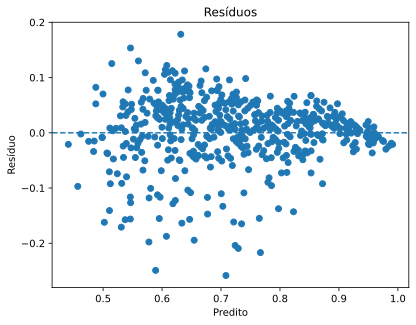

In [37]:
# calcular o residuo
y_pred = best_model.predict(X)
residuos = y - y_pred

# exbir o gráfico
plt.scatter(y_pred, residuos)
plt.axhline(0, linestyle='--')
plt.xlabel('Predito')
plt.ylabel('Resíduo')
plt.title("Resíduos")
plt.show()

### 9. Carrega database de Biomassa e pré-processa

In [38]:
scaler = MinMaxScaler()

df = load_df(DF_BIOMASSA)

y = df['biomassa']
X = df.drop('biomassa', axis = 1)


# Preprocessa features
X = scaler.fit_transform(X)


### 10. Treina em diferentes modelos e armazena os resultados

In [39]:
resultado_biomassa = testa_modelos(modelos, X, y)

Executando: KNN
  Melhor score: 0.72
  Melhor parâmetro: {'n_neighbors': 1}
--------------------------------------------------------------------------------
Executando: RNA - Hold Out
  Melhor score: 0.86
  Melhor parâmetro: {'hidden_layer_sizes': (30, 10), 'learning_rate_init': 0.1}
--------------------------------------------------------------------------------
Executando: RNA - Cross Validation
  Melhor score: 0.79
  Melhor parâmetro: {'hidden_layer_sizes': (30, 10), 'learning_rate_init': 0.1}
--------------------------------------------------------------------------------
Executando: SVM - Hold Out
  Melhor score: 0.08
  Melhor parâmetro: {'C': 100, 'gamma': 'scale'}
--------------------------------------------------------------------------------
Executando: SVM - Cross Validation
  Melhor score: 0.27
  Melhor parâmetro: {'C': 100, 'gamma': 'auto'}
--------------------------------------------------------------------------------
Executando: Random Forest - Hold Out
  Melhor score: 0

In [40]:
df_resultados_biomassa = pd.DataFrame.from_dict(resultado_biomassa, orient="index")

# Ordena pelo melhor score
df_resultados_biomassa = df_resultados_biomassa.sort_values("R2", ascending=False)

print(df_resultados_biomassa[[
    "nome",
    "melhor_parametro",
    "R2",
    "Syx",
    "Pearson",
    "RMSE",
    "MAE"
    
]].to_string(index=False))

                            nome                                            melhor_parametro   R2     Syx  Pearson    RMSE    MAE
                  RNA - Hold Out {'hidden_layer_sizes': (30, 10), 'learning_rate_init': 0.1} 0.86  821.21     0.98  825.76 187.34
          RNA - Cross Validation {'hidden_layer_sizes': (30, 10), 'learning_rate_init': 0.1} 0.79 1293.72     0.67 1291.71 424.36
                             KNN                                          {'n_neighbors': 1} 0.72 1749.70     0.87 1763.50 330.39
        Random Forest - Hold Out                       {'max_depth': 10, 'n_estimators': 10} 0.68 1403.64     0.93 1410.16 253.96
          SVM - Cross Validation                                 {'C': 100, 'gamma': 'auto'} 0.27 1420.24     0.07 1452.67 356.63
Random Forest - Cross Validation                    {'max_depth': None, 'n_estimators': 100} 0.25  775.91     0.87  775.42 132.19
                  SVM - Hold Out                                {'C': 100, 'gamma': 'scale

### 11. Faz predição para dados novos de Biomassa usando o melhor modelo

In [41]:
# obtem o melhor modelo
best_model_name = df_resultados_biomassa["nome"].iloc[0]
best_model = df_resultados_biomassa["modelo"].iloc[0]
print(best_model_name)

# carrega novos dados
X_novo = load_df(DADOS_NOVOS_BIOMASSA)

# Preprocessa features
X_novo = scaler.transform(X_novo)

# faz a predição
y_novo = np.round(best_model.predict(X_novo),2)
print(y_novo.tolist())


RNA - Hold Out
[32.41, 70.84, 24.68, 73.91]


### 12. Gráfico dos resíduos da melhor predição

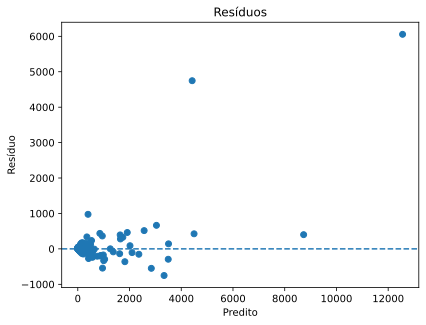

In [42]:
# calcular o residuo
y_pred = best_model.predict(X)
residuos = y - y_pred

# exbir o gráfico
plt.scatter(y_pred, residuos)
plt.axhline(0, linestyle='--')
plt.xlabel('Predito')
plt.ylabel('Resíduo')
plt.title("Resíduos")
plt.show()